In [1]:
import numpy as np
import cvxpy as cp
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os

19
19


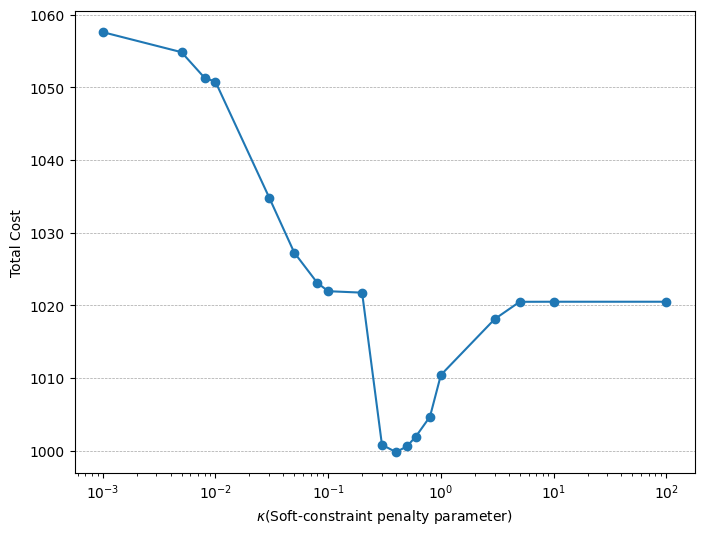

In [2]:
wws = [100,     10,      5,      3,       1,       0.8,     0.6,     0.5,     0.4, 
       0.3,     0.2,     0.1,    0.08,    0.05,    0.03,    0.01,    0.008,   0.005,   
       0.001]
tcs = [1020.51, 1020.51, 1020.5, 1018.12, 1010.43, 1004.69, 1001.96, 1000.61, 999.81,  
       1000.82, 1021.76, 1021.96,1023.12, 1027.28, 1034.84, 1050.80, 1051.34, 1054.86, 
       1057.62]
print(len(wws))
print(len(tcs))

plt.figure(figsize=(8, 6))

# Plot the data with markers
plt.plot(wws, tcs, marker='o')

# Set the x-axis to a logarithmic scale
plt.xscale('log')
plt.grid(axis='y', color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
# Add labels for clarity (title is removed)
plt.xlabel(r'$\kappa$(Soft-constraint penalty parameter)')
plt.ylabel('Total Cost')

# --- EXPORT TO PDF ---
# Save the figure to a PDF file. Use bbox_inches='tight' to remove extra white space.
# This should be called before plt.show()
plt.savefig(f"figures/ww sensitivity analysis log.pdf", bbox_inches='tight')

# Display the final plot on the screen
plt.show()

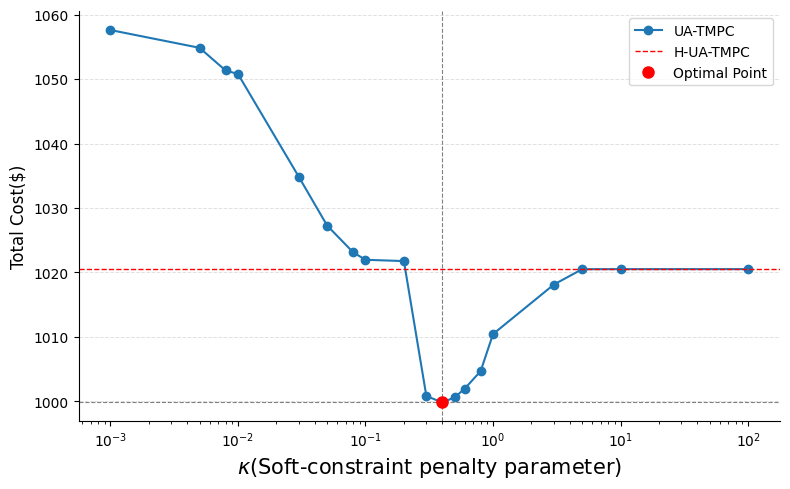

In [3]:
zeta_values = [100,     10,      5,      3,       1,       0.8,     0.6,     0.5,     0.4, 
       0.3,     0.2,     0.1,    0.08,    0.05,    0.03,    0.01,    0.008,   0.005,   
       0.001]
total_cost = [1020.51, 1020.51, 1020.5, 1018.12, 1010.43, 1004.69, 1001.96, 1000.61, 999.81,  
       1000.82, 1021.76, 1021.96,1023.12, 1027.28, 1034.84, 1050.80, 1051.34, 1054.86, 
       1057.62]

# ----- 核心绘图代码 -----

# 1. 创建图和坐标轴
fig, ax = plt.subplots(figsize=(8, 5))

# 2. 绘制主数据线
ax.plot(zeta_values, total_cost, marker='o', linestyle='-', label='UA-TMPC')
ax.axhline(y=1020.51, color='red', linestyle='--', linewidth=1, label='H-UA-TMPC')
# 3. 找出并高亮最低点
min_cost_index = np.argmin(total_cost)
optimal_zeta = zeta_values[min_cost_index]
min_cost = total_cost[min_cost_index]

# 用醒目的颜色和更大的点标记最低点
ax.plot(optimal_zeta, min_cost, 'o', color='red', markersize=8, label='Optimal Point', zorder=10)

# 4. 添加从最低点引出的虚线参考线
ax.axhline(y=min_cost, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=optimal_zeta, color='gray', linestyle='--', linewidth=0.8)

# 5. 设置坐标轴
ax.set_xscale('log') # X轴使用对数刻度
ax.set_xlabel(r'$\kappa$(Soft-constraint penalty parameter)', fontsize=15)
ax.set_ylabel('Total Cost($)', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10) # 调整刻度字体大小

# 6. 美化图表框架和网格线
# 只保留左边和底部的边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 添加柔和的水平网格线
ax.grid(axis='y', color='lightgray', linestyle='--', linewidth=0.7, alpha=0.7)

ax.legend()
# 7. 调整布局以避免标签被裁剪
plt.tight_layout()
plt.savefig(f"figures/ww sensitivity analysis log.pdf", bbox_inches='tight')
# 显示图形
plt.show()

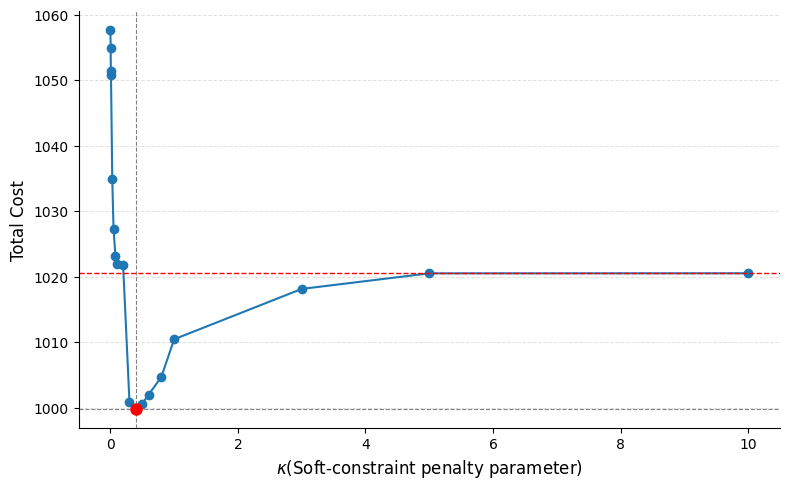

In [26]:
zeta_values = [10,      5,      3,       1,       0.8,     0.6,     0.5,     0.4, 
       0.3,     0.2,     0.1,    0.08,    0.05,    0.03,    0.01,    0.008,   0.005,   
       0.001]
total_cost = [1020.51, 1020.5, 1018.12, 1010.43, 1004.69, 1001.96, 1000.61, 999.81,  
       1000.82, 1021.76, 1021.96,1023.12, 1027.28, 1034.84, 1050.80, 1051.34, 1054.86, 
       1057.62]

# ----- 核心绘图代码 -----

# 1. 创建图和坐标轴
fig, ax = plt.subplots(figsize=(8, 5))

# 2. 绘制主数据线
ax.plot(zeta_values, total_cost, marker='o', linestyle='-', label='Total Cost')

# 3. 找出并高亮最低点
min_cost_index = np.argmin(total_cost)
optimal_zeta = zeta_values[min_cost_index]
min_cost = total_cost[min_cost_index]

# 用醒目的颜色和更大的点标记最低点
ax.plot(optimal_zeta, min_cost, 'o', color='red', markersize=8, label='Optimal Point', zorder=10)
ax.axhline(y=1020.51, color='red', linestyle='--', linewidth=1)
# 4. 添加从最低点引出的虚线参考线
ax.axhline(y=min_cost, color='gray', linestyle='--', linewidth=0.8)
ax.axvline(x=optimal_zeta, color='gray', linestyle='--', linewidth=0.8)

# 5. 设置坐标轴
# ax.set_xscale('log') # X轴使用对数刻度
ax.set_xlabel(r'$\kappa$(Soft-constraint penalty parameter)', fontsize=12)
ax.set_ylabel('Total Cost', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=10) # 调整刻度字体大小

# 6. 美化图表框架和网格线
# 只保留左边和底部的边框
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# 添加柔和的水平网格线
ax.grid(axis='y', color='lightgray', linestyle='--', linewidth=0.7, alpha=0.7)

# 7. 调整布局以避免标签被裁剪
plt.tight_layout()
plt.savefig(f"figures/ww sensitivity analysis.pdf", bbox_inches='tight')
# 显示图形
plt.show()